# GADM Administrative Units

Every administrative boundary in the world, at up to four levels of nesting, from the Database of
Global Administrative Areas. It is the unit geometry a disaster gets placed onto, and the answer to
"which polygon is this identifier".

## Provenance

These are the fields of the `GADM` declaration in `climate_risk/data/gadm.py`. It is a
`ManualSource`: the GeoPackage is downloaded from the GADM site by hand and placed in the cache.
Read the license row before doing anything commercial with a map made from it.

In [1]:
import dataclasses

from IPython.display import Markdown

from climate_risk.data.gadm import GADM

declared = {"publisher": "GADM"} | dataclasses.asdict(GADM)
rows = [f"| {field} | {value} |" for field, value in declared.items()]

Markdown("\n".join(["| Field | Value |", "|---|---|", *rows]))

| Field | Value |
|---|---|
| publisher | GADM |
| filename | gadm_410.gpkg |
| homepage | https://gadm.org/download_world.html |
| license | Academic use and other non-commercial use only. Redistribution, and use as part of a commercial product or service, require prior written permission. |
| citation | GADM, Database of Global Administrative Areas, version 4.1. https://gadm.org |
| retrieved | 2026-08-09 |

## Loading it

Two loaders read the GeoPackage. `load_units_in_country` answers "what units are there" for one
country at one level, which is what a search by geometry needs. `load_admin_units` answers "which
polygon is this identifier" for a set of ids you already have. The cache directory is your choice,
and this page uses one named `data` in the working directory.

In [2]:
import logging

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from climate_risk.data.gadm import load_admin_units, load_units_in_country
from climate_risk.plotting import PALETTE, configure_plot_style

configure_plot_style(add_grid=True)

# The package installs an INFO handler when nothing else has, and a cache hit logs a line.
logging.getLogger("climate_risk").setLevel(logging.WARNING)

In [3]:
cache_dir = Path("data")
COUNTRY = "THA"

provinces = load_units_in_country(COUNTRY, 1, cache_dir)
districts = load_units_in_country(COUNTRY, 2, cache_dir)

## What you get

A GeoDataFrame in EPSG:4326 with four columns, one row per unit. The same four columns come back
whichever level you ask for, so `admin_level` is what tells them apart once two frames are
concatenated.

In [4]:
provinces.head()

,gid,name,admin_level,geometry
0,THA.10_1,Chiang Mai,1,"POLYGON ((98.53622 17.54229, 98.53782 17.53923..."
1,THA.11_1,Chiang Rai,1,"POLYGON ((99.39837 19.00407, 99.39765 19.00651..."
2,THA.12_1,Chon Buri,1,"MULTIPOLYGON (((100.91604 12.60313, 100.91611 ..."
3,THA.13_1,Chumphon,1,"MULTIPOLYGON (((98.76792 9.67584, 98.76733 9.6..."
4,THA.14_1,Kalasin,1,"POLYGON ((103.41185 16.28391, 103.41149 16.284..."


In [5]:
# Identifiers taken from the frames above rather than written out, because their shape varies by
# country and cannot be guessed.
wanted = [(provinces["gid"].iloc[0], 1), (districts["gid"].iloc[0], 2)]

load_admin_units(wanted, cache_dir).drop(columns="geometry")

,gid,name,admin_level
0,THA.1.1_1,Chanuman,2
1,THA.10_1,Chiang Mai,1


## Units

| Column | Unit |
|---|---|
| `gid` | GADM identifier, as the GeoPackage spells it |
| `name` | unit name, as GADM spells it |
| `admin_level` | 1 through 4, the level asked for |
| `geometry` | polygon, degrees in EPSG:4326 |

There is no area column. Area in square kilometers is a projection away, and GADM leaves the choice
of projection to you rather than baking one in.

## Coverage

How finely a country is divided varies, and the levels run out at different depths. Thailand has
three, and asking for a fourth returns an empty frame rather than raising.

In [6]:
pd.DataFrame(
    [{"level": level, "units": len(load_units_in_country(COUNTRY, level, cache_dir))} for level in (1, 2, 3, 4)]
)

,level,units
0,1,77
1,2,928
2,3,5926
3,4,0


## A plot

Thailand's districts, with the province boundaries drawn over them. The nesting is the point: a
level-2 unit sits inside exactly one level-1 unit, and the identifier records which.

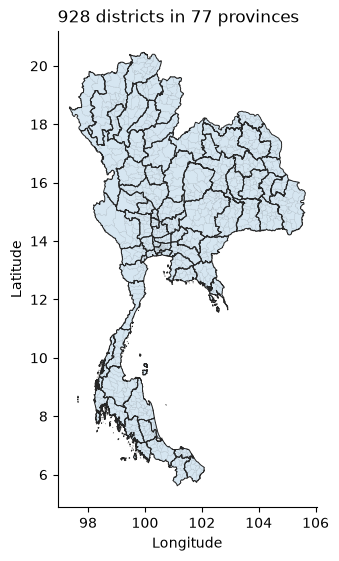

In [7]:
figure, axis = plt.subplots(figsize=(5.0, 5.5))
districts.plot(ax=axis, color=PALETTE["primary"], alpha=0.18, edgecolor=PALETTE["divider"], lw=0.2)
provinces.boundary.plot(ax=axis, color=PALETTE["observed"], lw=0.7)

axis.set_title(f"{len(districts)} districts in {len(provinces)} provinces", loc="left")
axis.set_xlabel("Longitude")
axis.set_ylabel("Latitude")
axis.grid(False)

plt.show()

## Gotchas

*Non-commercial use only.* Academic and other non-commercial use is free. Redistribution, and use in
a commercial product or service, need written permission from GADM. This is the most restrictive
license in the gallery.

*A GADM identifier does not state its level.* The trailing number is not it: Thailand's provinces
are `THA.1_1` and its districts `THA.1.1_1`, both ending in `_1`. Dot depth is not it either, since
Ghana's units are `GHA11_2` and `GHA7.13_2`. This is why `load_admin_units` takes the level from the
caller instead of parsing the id, and why an id written out by hand is a guess.

*Levels run out at different depths.* Thailand stops at three and returns an empty frame for four.
Code that assumes every country reaches a given level silently processes nothing for those that do
not.

*Names disagree with GAUL.* The Geo-Disasters footprints are GAUL 2015 units, and GADM spells and
subdivides differently. Joining the two by name rather than by geometry drops units without saying
so.

*One table holds every country.* The GeoPackage is a single layer at the finest level available, so
a unit above that is the union of its rows, and reading it means a query rather than opening a
country's file.